# 02 — Atmospheric and geometric configuration

All radiative simulations in `adjeff` are driven by three Pydantic configuration objects:

| Object | What it describes |
|---|---|
| `AtmoConfig` | Atmospheric state: aerosol optical thickness, humidity, species |
| `GeoConfig` | Sun/satellite geometry: angles, satellite height |
| `SpectralConfig` | Spectral bands and wavelengths |

Each accepts scalar values or xarray `DataArray` objects with named dimensions, enabling parameter sweeps.

**No GPU required for this notebook.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import structlog

from adjeff.atmosphere import AtmoConfig, GeoConfig, SpectralConfig
from adjeff.core import S2Band

# Disable logging
structlog.configure(
    processors=[
        structlog.processors.KeyValueRenderer(key_order=["event"]),
    ],
    logger_factory=structlog.PrintLoggerFactory(file=open("/dev/null", "w")),
)

## 2.1 — AtmoConfig

| Parameter | Unit | Description |
|---|---|---|
| `aot` | dimensionless | Aerosol optical thickness at the band wavelength |
| `h` | km | Ground elevation above sea level |
| `rh` | % | Relative humidity (0–100) |
| `href` | km | Reference height of the exponential aerosol vertical profile |
| `species` | — | Species mix (dict of str → float, must sum to 1.0) |

All array parameters must be 0-D scalars or 1-D `DataArray` objects with a dimension name matching the parameter.

In [2]:
# Scalar configuration (single atmospheric state)
atmo_scalar = AtmoConfig(
    aot=xr.DataArray([0.1], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)
print(atmo_scalar)

aot=<xarray.DataArray (aot: 1)> Size: 8B
array([0.1])
Coordinates:
  * aot      (aot) float64 8B 0.1 h=<xarray.DataArray (h: 1)> Size: 8B
array([0.])
Coordinates:
  * h        (h) float64 8B 0.0 rh=<xarray.DataArray (rh: 1)> Size: 8B
array([50.])
Coordinates:
  * rh       (rh) float64 8B 50.0 href=<xarray.DataArray (href: 1)> Size: 8B
array([2.])
Coordinates:
  * href     (href) float64 8B 2.0 species={'sulphate': 1.0}


In [3]:
# Sweep configuration — vary aot and rh simultaneously
atmo_sweep = AtmoConfig(
    aot=xr.DataArray([0.05, 0.10, 0.20, 0.40], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([30.0, 60.0, 90.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)
# When used in a sampler, this produces a (4 aot × 3 rh) grid of simulations
print(f"aot values: {atmo_sweep.aot.values}")
print(f"rh  values: {atmo_sweep.rh.values}")

aot values: [0.05 0.1  0.2  0.4 ]
rh  values: [30. 60. 90.]


In [4]:
# Pydantic validates the inputs — species must sum to 1.0
try:
    AtmoConfig(
        aot=xr.DataArray([0.1], dims=["aot"]),
        h=xr.DataArray([0.0], dims=["h"]),
        rh=xr.DataArray([50.0], dims=["rh"]),
        href=xr.DataArray([2.0], dims=["href"]),
        species={"sulphate": 0.7, "carbonaceous": 0.2},  # sums to 0.9 → error
    )
except Exception as e:
    print(f"Validation error: {e}")

Validation error: 1 validation error for AtmoConfig
  Value error, Species proportions should be 1.0, not 0.8999999999999999. [type=value_error, input_value={'aot': <xarray.DataArray...7, 'carbonaceous': 0.2}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


## 2.2 — GeoConfig

| Parameter | Unit | Range | Description |
|---|---|---|---|
| `sza` | ° | 0–90 | Sun zenith angle |
| `saa` | ° | 0–360 | Sun azimuth angle |
| `vza` | ° | 0–90 | Viewing (satellite) zenith angle |
| `vaa` | ° | 0–360 | Viewing azimuth angle |
| `sat_height` | km | — | Satellite altitude (default 700 km) |

In [5]:
geo = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([10.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([120.0], dims=["vaa"]),
)

# The satellite ground projection offset (relative to nadir)
x_off, y_off = geo.satellite_relative_position
print(f"Satellite ground offset: ({x_off[0]:.3f} km, {y_off[0]:.3f} km)")

Satellite ground offset: (61.714 km, 106.893 km)


In [6]:
# Sweep over solar and viewing angles
geo_sweep = GeoConfig(
    sza=xr.DataArray(np.arange(0.0, 70.0, 10.0), dims=["sza"]),
    vza=xr.DataArray([0.0, 10.0, 20.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([120.0], dims=["vaa"]),
)
print(f"sza values: {geo_sweep.sza.values}")
print(f"vza values: {geo_sweep.vza.values}")

sza values: [ 0. 10. 20. 30. 40. 50. 60.]
vza values: [ 0. 10. 20.]


## 2.3 — SpectralConfig

`SpectralConfig` links band identifiers to their central wavelengths. The easiest way to build one is via `from_bands()`.

In [7]:
bands = [S2Band.B02, S2Band.B03, S2Band.B04, S2Band.B08]
spectral = SpectralConfig.from_bands(bands)

print(f"Wavelengths: {spectral.wl.values} nm")
print(f"Bands      : {spectral.bands}")

Wavelengths: [490. 560. 665. 842.] nm
Bands      : [S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm), S2Band.B08(842.0nm)]


## 2.4 — Spatial parameter maps

Config parameters can carry spatial dimensions `(x, y)` to represent spatially varying atmospheres. This is useful for real imagery where the atmosphere varies across the scene.

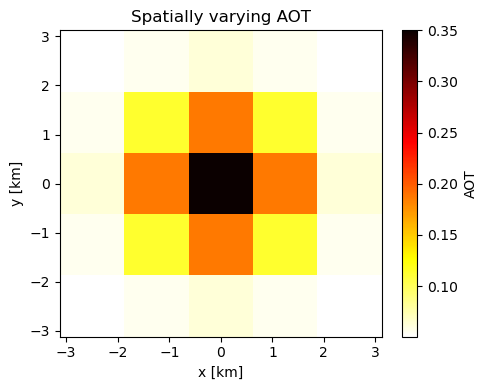

Total pixels: 25, unique AOT values: 6


In [8]:
nx, ny = 5, 5
x = np.linspace(-2.5, 2.5, nx)
y = np.linspace(-2.5, 2.5, ny)

# AOT varying spatially (e.g. from smoke plume)
X, Y = np.meshgrid(x, y)
aot_map = xr.DataArray(
    0.05 + 0.3 * np.exp(-(X**2 + Y**2) / 2.0),
    dims=["x", "y"],
    coords={"x": x, "y": y},
)

atmo_spatial = AtmoConfig(
    aot=aot_map,
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

plt.figure(figsize=(5, 4))
plt.pcolormesh(x, y, aot_map.values, cmap="hot_r")
plt.colorbar(label="AOT")
plt.title("Spatially varying AOT")
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.tight_layout()
plt.show()

# When passed to a sampler with deduplicate_dims=["x", "y"],
# only unique AOT values will be simulated → major speedup
n_unique = len(np.unique(aot_map.values.round(6)))
print(f"Total pixels: {nx * ny}, unique AOT values: {n_unique}")